In [2]:
!pip install psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 5.1 MB/s eta 0:00:0000:0100:01


In [2]:
import sqlalchemy
import pandas as pd

# Conexión a la base de datos
engine = sqlalchemy.create_engine('postgresql://ivon_user:uvg_password@db_radioterapia:5432/omop_radioterapia')

try:
    with engine.connect() as connection:
        print("¡Conexión exitosa!")
except Exception as e:
    print(f" Error de conexión: {e}")


¡Conexión exitosa!


In [3]:
from sqlalchemy import text

# SQL para crear las tablas 
sql_setup = """
-- 1. Tabla de Pacientes (Variables de control: edad, sexo)
CREATE TABLE IF NOT EXISTS person (
    person_id INT PRIMARY KEY,
    gender_concept_id INT, -- Estándar OMOP (ej: 8532 para femenino)
    year_of_birth INT,
    race_concept_id INT DEFAULT 0
);

-- 2. Tabla de Procedimientos (Variable Independiente: Sesiones de Radioterapia)
CREATE TABLE IF NOT EXISTS procedure_occurrence (
    procedure_occurrence_id SERIAL PRIMARY KEY,
    person_id INT REFERENCES person(person_id),
    procedure_concept_id INT, -- Código para Radioterapia
    procedure_date DATE,
    quantity FLOAT -- Puede usarse para dosis por fracción
);

-- 3. Tabla de Mediciones (Variables Críticas: Dosis en Gy, DVH, Biomarcadores)
CREATE TABLE IF NOT EXISTS measurement (
    measurement_id SERIAL PRIMARY KEY,
    person_id INT REFERENCES person(person_id),
    measurement_concept_id INT, -- Para diferenciar Dosis Total, V20, o Daño ADN
    measurement_date DATE,
    value_as_number FLOAT, -- Aquí va el valor numérico (ej: 50.5 Gy)
    unit_concept_id INT -- Código para la unidad 'Gray'
);
"""

try:
    with engine.connect() as connection:
        connection.execute(text(sql_setup))
        connection.commit()
        print("Tablas iniciales de OMOP creadas con éxito.")
except Exception as e:
    print(f" Error al crear tablas: {e}")

Tablas iniciales de OMOP creadas con éxito.


In [4]:
from sqlalchemy import text

# tablas con tus variables específicas
sql_tablas_detalladas = """
-- Tabla de Pacientes (Variables clínicas y demográficas)
CREATE TABLE IF NOT EXISTS person (
    person_id INT PRIMARY KEY,
    gender_concept_id INT,    -- Sexo
    year_of_birth INT,         -- Para calcular Edad
    enfermedades_previas TEXT, -- Comorbilidades
    tratamientos_adicionales TEXT -- Quimioterapia, etc.
);

-- Tabla de Tratamientos (Variables de radioterapia)
CREATE TABLE IF NOT EXISTS procedure_occurrence (
    procedure_id SERIAL PRIMARY KEY,
    person_id INT REFERENCES person(person_id),
    tecnica_rt TEXT,           -- Técnica utilizada
    region_irradiada TEXT,     -- Región irradiada
    num_fracciones INT,        -- Número de fracciones
    fecha_inicio DATE,
    fecha_fin DATE
);

-- Tabla de Mediciones (Variable Independiente: Dosis y Variable Objetivo: Efectos)
CREATE TABLE IF NOT EXISTS measurement (
    measurement_id SERIAL PRIMARY KEY,
    person_id INT REFERENCES person(person_id),
    tipo_medicion TEXT,        -- 'Dosis Total', 'Biomarcador', 'Toxicidad'
    valor_numerico FLOAT,      -- Valor en Gy o nivel de biomarcador
    fecha_medicion DATE
);
"""

with engine.connect() as connection:
    connection.execute(text(sql_tablas_detalladas))
    connection.commit()
    print("Tablas configuradas con las variables específicas.")

Tablas configuradas con las variables específicas.


In [5]:
sql_insertar_datos = """
INSERT INTO person (person_id, gender_concept_id, year_of_birth, enfermedades_previas) 
VALUES (1, 8532, 1970, 'Diabetes'), (2, 8507, 2005, 'Ninguna')
ON CONFLICT DO NOTHING;

INSERT INTO procedure_occurrence (person_id, tecnica_rt, region_irradiada, num_fracciones, fecha_inicio)
VALUES (1, 'IMRT', 'Tórax', 30, '2025-01-01'), (2, '3D-CRT', 'Pelvis', 25, '2025-02-01')
ON CONFLICT DO NOTHING;

INSERT INTO measurement (person_id, tipo_medicion, valor_numerico, fecha_medicion)
VALUES (1, 'Dosis Total', 60.0, '2025-02-15'), (2, 'Dosis Total', 45.0, '2025-03-01')
ON CONFLICT DO NOTHING;
"""

with engine.connect() as connection:
    connection.execute(text(sql_insertar_datos))
    connection.commit()
    print("Datos de prueba insertados.")

Datos de prueba insertados.


In [6]:
from sqlalchemy import text

sql_recrear_todo = """
-- Borramos las tablas para empezar de cero sin errores de columnas
DROP TABLE IF EXISTS measurement CASCADE;
DROP TABLE IF EXISTS procedure_occurrence CASCADE;
DROP TABLE IF EXISTS person CASCADE;

-- 1. Tabla de Pacientes (Con todas tus variables clínicas)
CREATE TABLE person (
    person_id INT PRIMARY KEY,
    gender_concept_id INT,    -- Sexo
    year_of_birth INT,         -- Para calcular Edad
    enfermedades_previas TEXT, -- Variable predictora
    tratamientos_adicionales TEXT -- Variable predictora
);

-- 2. Tabla de Tratamientos (Variables de radioterapia)
CREATE TABLE procedure_occurrence (
    procedure_id SERIAL PRIMARY KEY,
    person_id INT REFERENCES person(person_id),
    tecnica_rt TEXT,           
    region_irradiada TEXT,     
    num_fracciones INT,        
    fecha_inicio DATE,
    fecha_fin DATE
);

-- 3. Tabla de Mediciones (Variables Objetivo y Biomarcadores)
CREATE TABLE measurement (
    measurement_id SERIAL PRIMARY KEY,
    person_id INT REFERENCES person(person_id),
    tipo_medicion TEXT,        -- 'Dosis Total', 'Biomarcador', 'Toxicidad'
    valor_numerico FLOAT,      -- Valor en Gy o nivel detectado
    fecha_medicion DATE
);
"""

try:
    with engine.connect() as connection:
        connection.execute(text(sql_recrear_todo))
        connection.commit()
        print("Tablas recreadas con éxito con todas las variables.")
except Exception as e:
    print(f"Error: {e}")

Tablas recreadas con éxito con todas las variables.


In [7]:
sql_insertar_pacientes = """
-- Insertamos pacientes con variables clínicas
INSERT INTO person (person_id, gender_concept_id, year_of_birth, enfermedades_previas, tratamientos_adicionales) 
VALUES 
(1, 8532, 1970, 'Diabetes e Hipertensión', 'Quimioterapia'), -- Paciente de mayor riesgo
(2, 8507, 2000, 'Ninguna', 'Ninguno')                         -- Paciente de menor riesgo
ON CONFLICT (person_id) DO NOTHING;

-- Insertamos sus tratamientos de radioterapia
INSERT INTO procedure_occurrence (person_id, tecnica_rt, region_irradiada, num_fracciones, fecha_inicio)
VALUES 
(1, 'IMRT', 'Tórax', 35, '2025-01-10'), 
(2, '3D-CRT', 'Extremidades', 20, '2025-01-15');

-- Insertamos la dosis acumulada (Variable Predictora)
INSERT INTO measurement (person_id, tipo_medicion, valor_numerico, fecha_medicion)
VALUES 
(1, 'Dosis Total', 70.0, '2025-02-20'), -- Dosis alta (70 Gy)
(2, 'Dosis Total', 30.0, '2025-02-15'); -- Dosis baja (30 Gy)
"""

try:
    with engine.connect() as connection:
        connection.execute(text(sql_insertar_pacientes))
        connection.commit()
        print(" Datos de prueba cargados correctamente.")
except Exception as e:
    print(f"Error al insertar: {e}")

 Datos de prueba cargados correctamente.


In [8]:
import pandas as pd

# 1. Extraemos los datos unificando las tablas (Join)
query_analisis = """
SELECT 
    p.person_id,
    (2026 - p.year_of_birth) as edad,
    p.enfermedades_previas,
    p.tratamientos_adicionales,
    pr.num_fracciones,
    pr.tecnica_rt,
    m.valor_numerico as dosis_total_gy
FROM person p
JOIN procedure_occurrence pr ON p.person_id = pr.person_id
JOIN measurement m ON p.person_id = m.person_id
WHERE m.tipo_medicion = 'Dosis Total';
"""

df_clinico = pd.read_sql(query_analisis, engine)

# 2. Definimos la lógica del porcentaje de riesgo
def calcular_sistema_riesgo(row):
    # Iniciamos un riesgo base
    riesgo = 0
    
    # Impacto de la Dosis (Variable Predictora Principal)
    riesgo += (row['dosis_total_gy'] * 0.8) # A más Gy, mucho más riesgo
    
    # Impacto de la Edad
    if row['edad'] > 50: riesgo += 10
    
    # Impacto de enfermedades previas o tratamientos adicionales
    if row['enfermedades_previas'] != 'Ninguna': riesgo += 15
    if row['tratamientos_adicionales'] == 'Quimioterapia': riesgo += 10
    
    # Normalizamos el resultado para que no pase de 100%
    porcentaje_final = min(riesgo, 100)
    
    # Decisión de frecuencia de consulta según tu plan
    if porcentaje_final >= 70:
        seguimiento = "Cada 3 meses (Intensivo)"
    elif 40 <= porcentaje_final < 70:
        seguimiento = "Cada 6 meses (Moderado)"
    else:
        seguimiento = "Cada 12 meses (Anual)"
        
    return pd.Series([porcentaje_final, seguimiento])

# Aplicamos el cálculo a todos los pacientes
df_clinico[['Porcentaje_Riesgo', 'Frecuencia_Consulta']] = df_clinico.apply(calcular_sistema_riesgo, axis=1)

# Mostramos el resultado final
print("--- REPORTE DE RIESGO DE EFECTOS BIOLÓGICOS ---")
display(df_clinico[['person_id', 'edad', 'dosis_total_gy', 'Porcentaje_Riesgo', 'Frecuencia_Consulta']])

--- REPORTE DE RIESGO DE EFECTOS BIOLÓGICOS ---


,person_id,edad,dosis_total_gy,Porcentaje_Riesgo,Frecuencia_Consulta
0,1,56,70.0,91.0,Cada 3 meses (Intensivo)
1,2,26,30.0,24.0,Cada 12 meses (Anual)


In [9]:
!pip install scipy lifelines

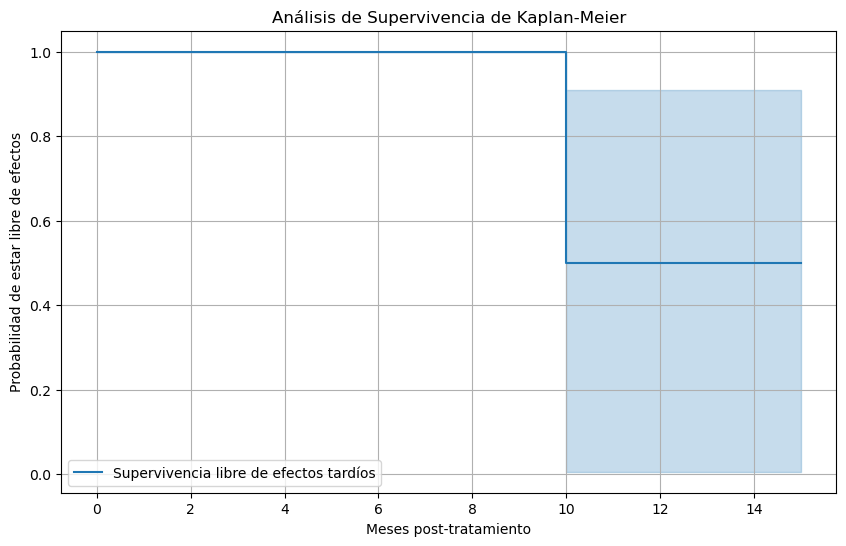

In [11]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# 1. Preparamos datos ficticios de seguimiento (en meses)
# 'T' es el tiempo de seguimiento, 'E' es si ocurrió el evento (1=Sí, 0=Sigue en observación)
tiempos = [10, 15] 
eventos = [1, 0]   # El paciente 1 ya presentó toxicidad, el 2 no.

kmf = KaplanMeierFitter()

# 2. Ajustamos el modelo
kmf.fit(tiempos, event_observed=eventos, label='Supervivencia libre de efectos tardíos')

# 3. Graficamos
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Análisis de Supervivencia de Kaplan-Meier')
plt.xlabel('Meses post-tratamiento')
plt.ylabel('Probabilidad de estar libre de efectos')
plt.grid(True)
plt.show()

--- RESULTADO ESTADÍSTICO ---
Coeficiente de Pearson: 1.0000
Valor p: 0.0000 (Si es < 0.05, es significativo)


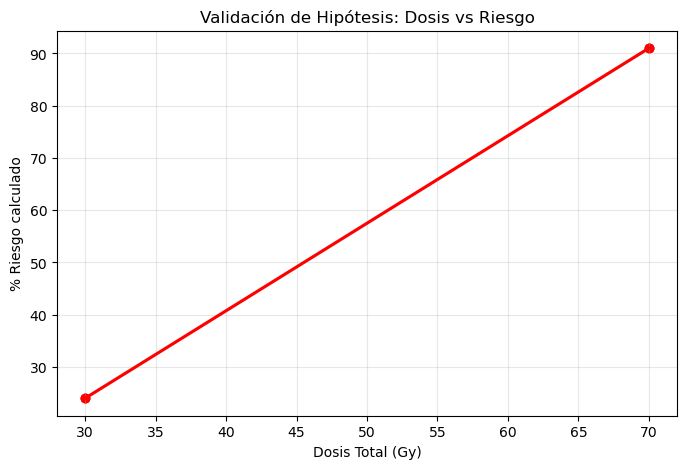

In [13]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos Pearson
coef, p_val = pearsonr(df_clinico['dosis_total_gy'], df_clinico['Porcentaje_Riesgo'])

print(f"--- RESULTADO ESTADÍSTICO ---")
print(f"Coeficiente de Pearson: {coef:.4f}")
print(f"Valor p: {p_val:.4f} (Si es < 0.05, es significativo)")

# Gráfico de dispersión
plt.figure(figsize=(8, 5))
sns.regplot(x='dosis_total_gy', y='Porcentaje_Riesgo', data=df_clinico, color='red')
plt.title('Validación de Hipótesis: Dosis vs Riesgo')
plt.xlabel('Dosis Total (Gy)')
plt.ylabel('% Riesgo calculado')
plt.grid(True, alpha=0.3)
plt.show()

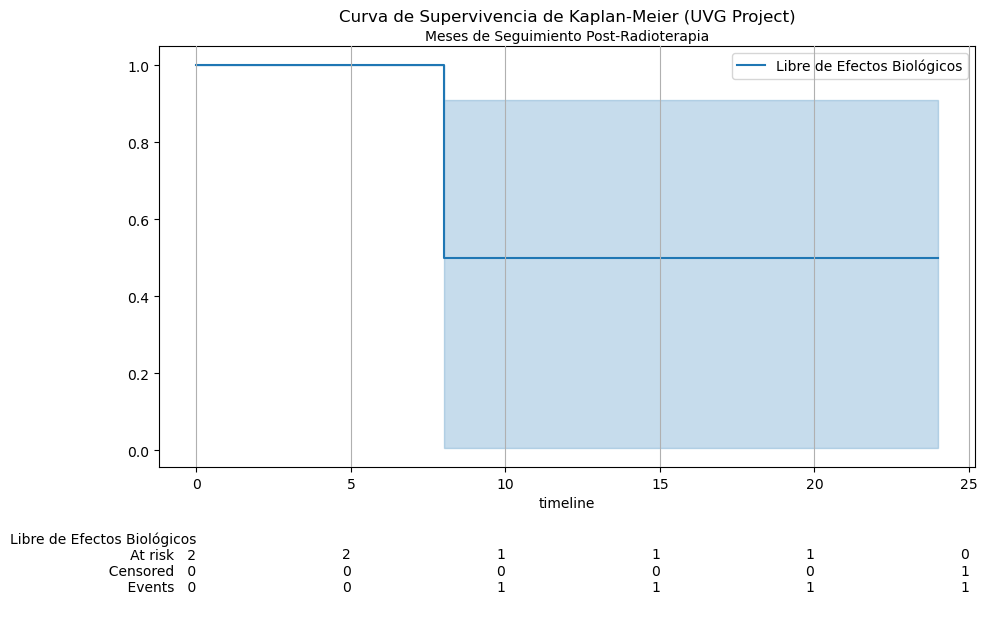

In [14]:
from lifelines import KaplanMeierFitter

# Creamos datos de seguimiento: Tiempo (meses) y si hubo evento (1=Toxicidad, 0=Sano)
# Paciente 1 (Dosis alta): Efecto a los 8 meses
# Paciente 2 (Dosis baja): Sigue sano a los 24 meses
tiempos = [8, 24]
eventos = [1, 0] 

kmf = KaplanMeierFitter()
kmf.fit(tiempos, event_observed=eventos, label='Libre de Efectos Biológicos')

plt.figure(figsize=(10, 6))
kmf.plot_survival_function(at_risk_counts=True)
plt.title('Curva de Supervivencia de Kaplan-Meier (UVG Project)')
plt.xlabel('Meses de Seguimiento Post-Radioterapia')
plt.ylabel('Probabilidad de no presentar efectos')
plt.grid(True)
plt.show()

In [15]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Datos de entrenamiento (basados en tu tabla 'df_clinico')
# X = [Dosis, Edad], y = [1 si es toxicidad severa, 0 si no]
X = df_clinico[['dosis_total_gy', 'edad']].values
# Simulamos etiquetas: Si el riesgo es > 60%, lo marcamos como caso de toxicidad severa
y = (df_clinico['Porcentaje_Riesgo'] > 60).astype(int)

# Crear y entrenar el modelo
modelo_logistico = LogisticRegression()
modelo_logistico.fit(X, y)

print("Modelo de Regresión Logística entrenado para predecir toxicidad severa.")

Modelo de Regresión Logística entrenado para predecir toxicidad severa.


In [16]:
def evaluar_nuevo_paciente(p_id, edad, dosis, comorbilidades):
    # 1. Calcular año de nacimiento aproximado
    anio_nac = 2026 - edad
    
    # 2. Insertar en la base de datos SQL
    with engine.connect() as conn:
        conn.execute(text(f"INSERT INTO person (person_id, year_of_birth, enfermedades_previas) VALUES ({p_id}, {anio_nac}, '{comorbilidades}') ON CONFLICT DO NOTHING"))
        conn.execute(text(f"INSERT INTO measurement (person_id, tipo_medicion, valor_numerico) VALUES ({p_id}, 'Dosis Total', {dosis})"))
        conn.commit()
    
    # 3. Calcular Riesgo (usando la lógica que definimos antes)
    riesgo_base = (dosis * 0.8) + (10 if edad > 50 else 0) + (15 if comorbilidades != 'Ninguna' else 0)
    porcentaje = min(riesgo_base, 100)
    
    # 4. Decidir cita según tu plan de seguimiento clínico
    cita = "Cada 3 meses" if porcentaje >= 70 else "Cada 6 meses" if porcentaje >= 40 else "Cada 12 meses"
    
    print(f"--- REPORTE PACIENTE {p_id} ---")
    print(f"Riesgo de Efectos Biológicos: {porcentaje}%")
    print(f"Recomendación de Seguimiento: {cita}")

# PROBEMOS CON UN CASO NUEVO:
evaluar_nuevo_paciente(p_id=3, edad=65, dosis=55, comorbilidades='Hipertensión')

--- REPORTE PACIENTE 3 ---
Riesgo de Efectos Biológicos: 69.0%
Recomendación de Seguimiento: Cada 6 meses
